# Hotel Recommendation System

## Project Objective

The objective of this module is to build a hotel recommendation system using historical travel, hotel, and user data.

The recommendation system will analyze available information such as user characteristics, travel destinations, hotel booking history, stay duration, and hotel prices to recommend suitable hotels to users.

The recommendation model will initially be developed and evaluated independently from the existing flight price prediction model. After successful validation, it can be integrated with the existing Streamlit application so that users can receive hotel recommendations along with their predicted flight price.



## Recommendation System Workflow

1. Data Understanding
2. Exploratory Data Analysis
3. Data Preparation and Integration
4. Recommendation Strategy Selection
5. Recommendation Model Development
6. Model Evaluation
7. Recommendation Testing
8. Integration with the Travel Analytics Application

## 1. Data Loading and Initial Understanding

The recommendation system uses three related datasets:

- **users.csv** — contains user demographic information.
- **flights.csv** — contains historical flight/travel information.
- **hotels.csv** — contains historical hotel booking information.

These datasets will be examined individually before determining how they should be combined for recommendation modeling.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Load datasets
users = pd.read_csv("../data/raw/users.csv")
flights = pd.read_csv("../data/raw/flights.csv")
hotels = pd.read_csv("../data/raw/hotels.csv")

print("Users shape:", users.shape)
print("Flights shape:", flights.shape)
print("Hotels shape:", hotels.shape)

Users shape: (1340, 5)
Flights shape: (271888, 10)
Hotels shape: (40552, 8)


In [3]:
display(users.head())

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


In [4]:
display(flights.head())

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


In [5]:
display(hotels.head())

,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


## 2. Recommendation Data Audit

Before selecting a recommendation algorithm, the interaction structure of the dataset must be examined.

Unlike explicit-feedback recommendation datasets, the hotel dataset does not contain a direct user rating or preference score. Therefore, historical hotel bookings may need to be treated as **implicit feedback**, where a booking represents an interaction between a user and a hotel.

The following analysis examines:

- Number of unique users
- Number of unique hotels
- Hotel locations
- Number of bookings per user
- Number of bookings per hotel
- Repeated hotel bookings
- User coverage across datasets
- Hotel availability by destination

These findings will help determine the most appropriate recommendation strategy.

In [6]:
# Basic recommendation-system statistics

recommendation_summary = pd.DataFrame({
    "Metric": [
        "Total hotel bookings",
        "Unique hotel users",
        "Unique hotels",
        "Unique hotel locations",
        "Unique travel codes"
    ],
    "Value": [
        len(hotels),
        hotels["userCode"].nunique(),
        hotels["name"].nunique(),
        hotels["place"].nunique(),
        hotels["travelCode"].nunique()
    ]
})

display(recommendation_summary)

,Metric,Value
0,Total hotel bookings,40552
1,Unique hotel users,1310
2,Unique hotels,9
3,Unique hotel locations,9
4,Unique travel codes,40552


### Insight: Basic Recommendation Statistics

- The hotel dataset contains **40,552 historical hotel bookings** made by **1,310 unique users**.
- There are **9 unique hotels across 9 unique locations**.
- Every hotel booking has a unique `travelCode`, indicating that each row represents a distinct hotel booking associated with a trip.
- The relatively large number of historical bookings per user provides useful behavioral information for studying user travel and hotel-booking patterns.
- However, the small number of unique hotels requires further investigation before selecting a recommendation algorithm.

In [7]:
user_booking_counts = (
    hotels.groupby("userCode")
    .size()
    .reset_index(name="booking_count")
    .sort_values("booking_count", ascending=False)
)

display(user_booking_counts.head(10))

display(
    user_booking_counts["booking_count"]
    .describe()
    .to_frame(name="Booking Count")
)

,userCode,booking_count
1078,1104,76
1294,1323,74
427,436,73
248,251,69
1112,1138,69
103,105,68
1223,1252,68
317,322,67
564,575,67
588,601,67


,Booking Count
count,1310.000000
mean,30.955725
std,17.975993
min,1.000000
25%,15.000000
50%,30.000000
75%,46.000000
max,76.000000


### Insight: Hotel Booking Frequency per User

- The dataset contains hotel-booking histories for **1,310 users**.
- A user has approximately **31 hotel bookings on average**, while the median is **30 bookings**.
- The number of bookings ranges from **1 to 76 per user**.
- Approximately 75% of users have up to **46 bookings**, while a smaller group of highly active users has more than 60 historical bookings.
- The distribution indicates that many users have repeated travel and hotel-booking interactions rather than only a single transaction.
- These repeated interactions provide useful behavioral information that could potentially support personalized recommendations.

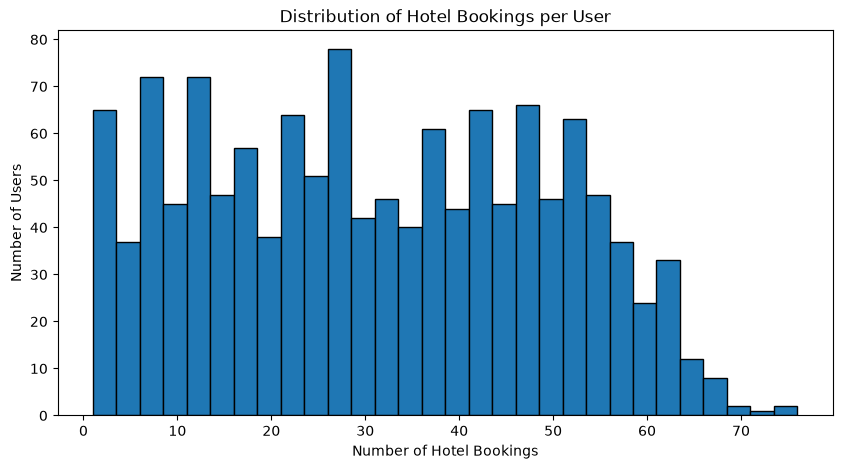

In [8]:
plt.figure(figsize=(10, 5))

plt.hist(
    user_booking_counts["booking_count"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Hotel Bookings per User")
plt.xlabel("Number of Hotel Bookings")
plt.ylabel("Number of Users")

plt.show()

In [9]:
hotel_booking_counts = (
    hotels.groupby("name")
    .size()
    .reset_index(name="booking_count")
    .sort_values("booking_count", ascending=False)
)

display(hotel_booking_counts)

,name,booking_count
7,Hotel K,5094
6,Hotel CB,5029
3,Hotel BD,4829
1,Hotel AF,4828
2,Hotel AU,4467
4,Hotel BP,4437
5,Hotel BW,4333
8,Hotel Z,4205
0,Hotel A,3330


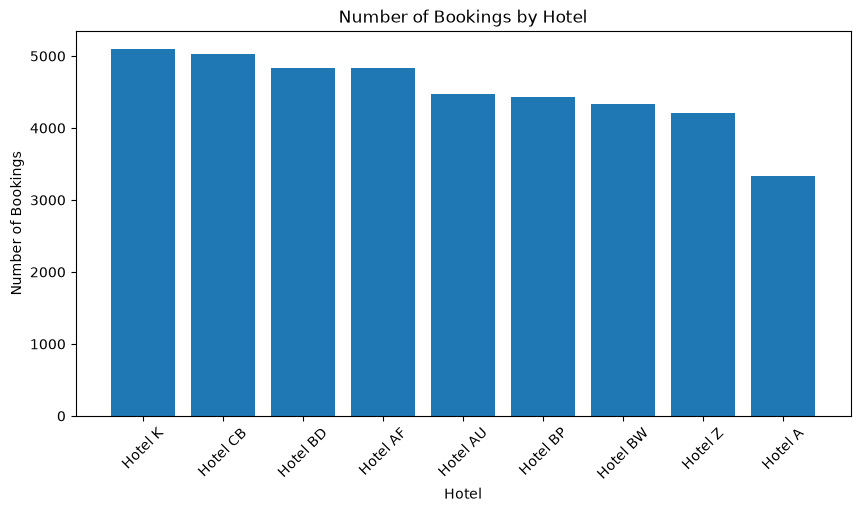

In [10]:
plt.figure(figsize=(10, 5))

plt.bar(
    hotel_booking_counts["name"],
    hotel_booking_counts["booking_count"]
)

plt.title("Number of Bookings by Hotel")
plt.xlabel("Hotel")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)

plt.show()

### Insight: Hotel Popularity

- **Hotel K** is the most frequently booked hotel with **5,094 bookings**, followed closely by **Hotel CB** with **5,029 bookings**.
- **Hotel A** has the lowest booking frequency with **3,330 bookings**.
- Booking activity is reasonably distributed across the nine hotels rather than being dominated by a single property.
- This indicates that all hotels receive substantial historical booking activity.
- Hotel popularity can potentially be used as one component of a recommendation score, particularly when personalized information is limited.

In [11]:
hotel_destination_summary = (
    hotels.groupby("place")
    .agg(
        unique_hotels=("name", "nunique"),
        total_bookings=("travelCode", "count"),
        average_price=("price", "mean"),
        average_stay_days=("days", "mean")
    )
    .reset_index()
    .sort_values("total_bookings", ascending=False)
)

display(hotel_destination_summary)

,place,unique_hotels,total_bookings,average_price,average_stay_days
7,Salvador (BH),1,5094,263.41,2.516490
6,Rio de Janeiro (RJ),1,5029,165.99,2.485981
4,Natal (RN),1,4829,242.88,2.499068
8,Sao Paulo (SP),1,4828,139.10,2.511599
5,Recife (PE),1,4467,312.83,2.520931
1,Brasilia (DF),1,4437,247.62,2.486365
2,Campo Grande (MS),1,4333,60.39,2.495500
0,Aracaju (SE),1,4205,208.04,2.491558
3,Florianopolis (SC),1,3330,313.02,2.483183


### Insight: Hotel Availability by Destination

- The dataset contains **9 hotel locations and 9 unique hotels**.
- Importantly, each destination contains only **one unique hotel**.
- Therefore, hotel identity appears to be directly associated with destination rather than representing multiple competing hotels within the same destination.
- For example, historical bookings for Salvador correspond to one hotel, while Rio de Janeiro bookings correspond to another single hotel.
- This creates an important limitation for a conventional destination-based hotel recommendation system because there are no alternative hotels to rank within the same destination.
- Consequently, recommending several hotels for one selected destination cannot be directly supported by the available data.
- Further analysis of user travel behavior, destination preferences, hotel-price preferences, company, age, gender, stay duration, and repeat-booking patterns is required before selecting the final recommendation methodology.

## 3. Hotel and Destination Relationship

The initial analysis shows that every destination contains only one unique hotel. Before designing the recommendation strategy, the relationship between hotel names and destinations is examined directly.

This analysis determines whether a hotel occurs in multiple destinations or whether each hotel represents a destination-specific property.

In [12]:
hotel_location_mapping = (
    hotels.groupby("name")
    .agg(
        locations=("place", "nunique"),
        location=("place", "first"),
        bookings=("travelCode", "count"),
        average_price=("price", "mean"),
        average_stay_days=("days", "mean")
    )
    .reset_index()
    .sort_values("bookings", ascending=False)
)

display(hotel_location_mapping)

,name,locations,location,bookings,average_price,average_stay_days
7,Hotel K,1,Salvador (BH),5094,263.41,2.516490
6,Hotel CB,1,Rio de Janeiro (RJ),5029,165.99,2.485981
3,Hotel BD,1,Natal (RN),4829,242.88,2.499068
1,Hotel AF,1,Sao Paulo (SP),4828,139.10,2.511599
2,Hotel AU,1,Recife (PE),4467,312.83,2.520931
4,Hotel BP,1,Brasilia (DF),4437,247.62,2.486365
5,Hotel BW,1,Campo Grande (MS),4333,60.39,2.495500
8,Hotel Z,1,Aracaju (SE),4205,208.04,2.491558
0,Hotel A,1,Florianopolis (SC),3330,313.02,2.483183


### Insight: Hotel–Destination Relationship

- Each of the **9 hotels is associated with exactly one destination**.
- No hotel appears across multiple destinations, and no destination contains multiple hotels.
- The mapping is therefore one-to-one between hotel and destination:
  - Hotel Z → Aracaju (SE)
  - Hotel BP → Brasilia (DF)
  - Hotel BW → Campo Grande (MS)
  - Hotel A → Florianopolis (SC)
  - Hotel BD → Natal (RN)
  - Hotel AU → Recife (PE)
  - Hotel CB → Rio de Janeiro (RJ)
  - Hotel K → Salvador (BH)
  - Hotel AF → Sao Paulo (SP)
- Hotel prices also differ considerably across destinations, ranging from approximately **60.39** for Hotel BW to **313.02** for Hotel A.
- Average stay duration is very similar across hotels at approximately **2.5 days**, suggesting that stay duration alone may provide limited differentiation between hotels.
- Because there is only one hotel per destination, a conventional system that ranks multiple hotels within a selected destination cannot be constructed directly from this dataset.
- Instead, the recommendation problem should investigate whether historical user behavior can be used to rank suitable **hotel–destination combinations** for each user.

In [13]:
location_hotel_pairs = (
    hotels[["place", "name"]]
    .drop_duplicates()
    .sort_values("place")
    .reset_index(drop=True)
)

display(location_hotel_pairs)

,place,name
0,Aracaju (SE),Hotel Z
1,Brasilia (DF),Hotel BP
2,Campo Grande (MS),Hotel BW
3,Florianopolis (SC),Hotel A
4,Natal (RN),Hotel BD
5,Recife (PE),Hotel AU
6,Rio de Janeiro (RJ),Hotel CB
7,Salvador (BH),Hotel K
8,Sao Paulo (SP),Hotel AF


## 4. User–Hotel Interaction Analysis

Since each hotel corresponds to a unique destination, hotel bookings can also represent a user's historical destination preferences.

To determine whether personalized recommendation is feasible, user–hotel interactions are analyzed by examining:

- Number of unique hotels visited by each user
- Distribution of hotel diversity across users
- Repeated bookings of the same hotel
- User–hotel interaction frequency
- Coverage and sparsity of the interaction matrix

These analyses help determine whether users exhibit sufficiently different historical booking patterns to support personalized recommendations.

In [14]:
user_hotel_diversity = (
    hotels.groupby("userCode")["name"]
    .nunique()
    .reset_index(name="unique_hotels_visited")
)

display(
    user_hotel_diversity["unique_hotels_visited"]
    .describe()
    .to_frame(name="Unique Hotels Visited")
)

,Unique Hotels Visited
count,1310.000000
mean,7.422901
std,1.882271
min,1.000000
25%,7.000000
50%,8.000000
75%,9.000000
max,9.000000


In [16]:
hotel_diversity_distribution = (
    user_hotel_diversity["unique_hotels_visited"]
    .value_counts()
    .sort_index()
    .reset_index()
)

hotel_diversity_distribution.columns = [
    "unique_hotels_visited",
    "number_of_users"
]

display(hotel_diversity_distribution)

,unique_hotels_visited,number_of_users
0,1,25
1,2,28
2,3,33
3,4,43
4,5,58
5,6,76
6,7,126
7,8,545
8,9,376


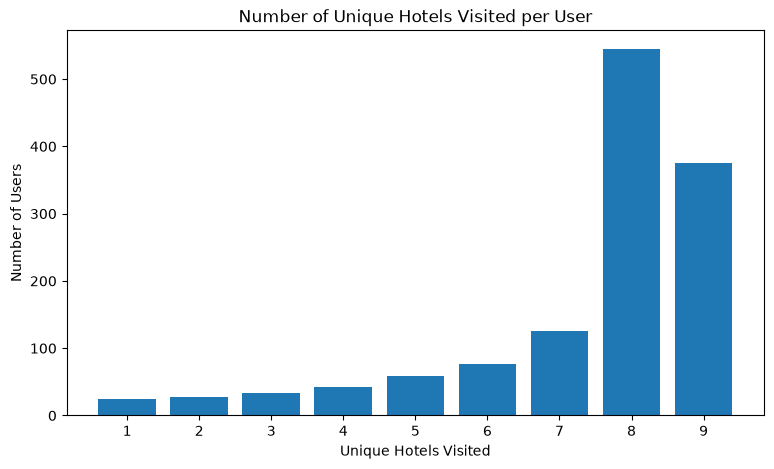

In [17]:
plt.figure(figsize=(9, 5))

plt.bar(
    hotel_diversity_distribution["unique_hotels_visited"],
    hotel_diversity_distribution["number_of_users"]
)

plt.title("Number of Unique Hotels Visited per User")
plt.xlabel("Unique Hotels Visited")
plt.ylabel("Number of Users")
plt.xticks(hotel_diversity_distribution["unique_hotels_visited"])

plt.show()

### Insight: User Hotel Diversity

- Users have visited an average of approximately **7.42 out of the 9 available hotels**.
- The median user has interacted with **8 hotels**, indicating broad historical coverage of the available hotel inventory.
- **545 users** have booked 8 different hotels, while **376 users** have booked all 9 hotels.
- Therefore, **921 out of 1,310 users (about 70.3%)** have interacted with at least 8 of the 9 available hotels.
- Only a relatively small number of users have interacted with one or two hotels.
- This indicates that the user–hotel interaction dataset is relatively dense rather than sparse.
- Although the rich booking history is useful for learning user preferences, the large number of users who have already interacted with nearly every hotel limits the number of completely unseen hotels available for traditional collaborative-filtering recommendations.

### User–Hotel Interaction Matrix

A user–hotel interaction matrix represents how frequently each user has booked each hotel.

Rows represent users, columns represent hotels, and values represent historical booking counts. This provides a compact representation of implicit user preferences and is useful for evaluating whether collaborative or personalized ranking approaches are suitable.

In [19]:
user_hotel_matrix = pd.crosstab(
    hotels["userCode"],
    hotels["name"]
)

display(user_hotel_matrix.head(10))

name,Hotel A,Hotel AF,Hotel AU,Hotel BD,Hotel BP,Hotel BW,Hotel CB,Hotel K,Hotel Z
userCode,,,,,,,,,
0,3,4,2,4,1,2,1,7,3
1,0,1,0,0,1,0,0,0,0
2,6,2,3,2,2,7,3,5,6
3,10,6,7,11,2,9,7,6,2
4,7,6,7,5,3,6,11,7,4
5,1,3,0,1,0,1,1,5,1
6,4,5,1,3,3,1,3,3,0
7,0,1,2,3,1,5,1,0,1
8,6,4,8,12,4,6,4,3,5


### Insight: User–Hotel Interaction Matrix

- The interaction matrix shows substantial variation in booking frequency across hotels for individual users.
- A value of zero represents no historical booking, while larger values indicate repeated interaction with a particular hotel.
- Many users have booked the same hotel multiple times, providing stronger preference information than a simple booked/not-booked indicator.
- For example, some users show considerably higher booking frequencies for particular hotels compared with others.
- Therefore, historical **booking frequency can be treated as an implicit preference signal**.
- Because many users have already visited most or all available hotels, the recommendation problem may be better framed as **ranking hotels according to predicted user preference** rather than only recommending previously unseen hotels.

In [20]:
user_hotel_matrix_with_total = user_hotel_matrix.copy()

user_hotel_matrix_with_total["Total Bookings"] = (
    user_hotel_matrix_with_total.sum(axis=1)
)

display(
    user_hotel_matrix_with_total
    .sort_values("Total Bookings", ascending=False)
    .head(10)
)

name,Hotel A,Hotel AF,Hotel AU,Hotel BD,Hotel BP,Hotel BW,Hotel CB,Hotel K,Hotel Z,Total Bookings
userCode,,,,,,,,,,
1104,0,6,10,7,13,16,12,6,6,76
1323,0,5,8,11,13,9,12,8,8,74
436,10,8,4,12,6,13,7,9,4,73
251,13,7,5,4,2,11,8,12,7,69
1138,0,8,6,8,10,10,7,6,14,69
105,6,10,6,8,7,11,4,10,6,68
1252,0,8,8,6,11,9,9,9,8,68
322,12,7,6,6,9,11,2,6,8,67
575,12,7,8,7,12,0,10,4,7,67


### Insight: Booking Frequency Among Highly Active Users

- Highly active users have substantial historical booking information, with the most active users recording approximately 67–76 hotel bookings.
- Booking frequencies are not distributed identically across hotels for each user.
- Some users repeatedly book particular hotels while having little or no interaction with others.
- These differences indicate the presence of user-specific behavioral patterns that may be useful for personalized ranking.
- Repeated booking frequency can therefore provide a stronger implicit preference signal than simply recording whether a user has ever visited a hotel.

### Interaction Matrix Sparsity

Recommendation datasets are often sparse because individual users interact with only a small proportion of all available items.

The sparsity of the user–hotel matrix measures the percentage of possible user–hotel interactions that have never occurred.

A lower sparsity indicates richer interaction histories, while very high sparsity can make collaborative recommendation more difficult.

In [21]:
total_possible_interactions = (
    user_hotel_matrix.shape[0] *
    user_hotel_matrix.shape[1]
)

observed_interactions = (
    user_hotel_matrix > 0
).sum().sum()

zero_interactions = (
    total_possible_interactions -
    observed_interactions
)

sparsity = (
    zero_interactions /
    total_possible_interactions
) * 100

interaction_summary = pd.DataFrame({
    "Metric": [
        "Users",
        "Hotels",
        "Possible user-hotel pairs",
        "Observed user-hotel pairs",
        "Zero user-hotel pairs",
        "Matrix sparsity (%)"
    ],
    "Value": [
        user_hotel_matrix.shape[0],
        user_hotel_matrix.shape[1],
        total_possible_interactions,
        observed_interactions,
        zero_interactions,
        round(sparsity, 2)
    ]
})

display(interaction_summary)

,Metric,Value
0,Users,1310.00
1,Hotels,9.00
2,Possible user-hotel pairs,11790.00
3,Observed user-hotel pairs,9724.00
4,Zero user-hotel pairs,2066.00
5,Matrix sparsity (%),17.52


### Insight: User–Hotel Interaction Matrix Sparsity

- The user–hotel interaction matrix contains **11,790 possible user–hotel combinations**.
- Of these, **9,724 interactions have been observed**, while **2,066 combinations have no historical booking**.
- The matrix sparsity is only **17.52%**, corresponding to an interaction density of approximately **82.48%**.
- This is considerably denser than many traditional recommendation datasets, where users typically interact with only a small fraction of available items.
- The high density occurs because there are only nine hotels and most users have booked a large proportion of them.
- Consequently, a conventional collaborative-filtering strategy focused only on discovering unseen hotels may have limited usefulness.
- However, repeated booking frequencies provide additional implicit preference information that can potentially be used to rank hotels according to user-specific historical behavior.

## 5. Repeated Booking and User Preference Analysis

Because most users have interacted with a large proportion of the available hotels, simply distinguishing between visited and unvisited hotels may not provide sufficient personalization.

Repeated booking frequency can provide a stronger implicit signal of preference. This section examines how concentrated each user's bookings are among their historically visited hotels.

In [22]:
# Maximum number of bookings made by each user for a single hotel
user_preference_strength = pd.DataFrame({
    "total_bookings": user_hotel_matrix.sum(axis=1),
    "unique_hotels": (user_hotel_matrix > 0).sum(axis=1),
    "max_hotel_bookings": user_hotel_matrix.max(axis=1)
})

# Percentage of a user's bookings belonging to their most-booked hotel
user_preference_strength["top_hotel_share_pct"] = (
    user_preference_strength["max_hotel_bookings"]
    / user_preference_strength["total_bookings"]
    * 100
)

display(user_preference_strength.head(10))

display(
    user_preference_strength[
        ["total_bookings", "unique_hotels",
         "max_hotel_bookings", "top_hotel_share_pct"]
    ]
    .describe()
    .round(2)
)

,total_bookings,unique_hotels,max_hotel_bookings,top_hotel_share_pct
userCode,,,,
0,27,9,7,25.925926
1,2,2,1,50.000000
2,36,9,7,19.444444
3,60,9,11,18.333333
4,56,9,11,19.642857
5,13,7,5,38.461538
6,23,8,5,21.739130
7,14,7,5,35.714286
8,52,9,12,23.076923


,total_bookings,unique_hotels,max_hotel_bookings,top_hotel_share_pct
count,1310.00,1310.00,1310.00,1310.00
mean,30.96,7.42,6.61,25.74
std,17.98,1.88,3.33,13.32
min,1.00,1.00,1.00,13.33
25%,15.00,7.00,4.00,19.05
50%,30.00,8.00,7.00,22.13
75%,46.00,9.00,9.00,27.27
max,76.00,9.00,18.00,100.00


### Insight: Individual User Preference Strength

- Users exhibit different levels of concentration in their historical hotel-booking behavior.
- Some users distribute their bookings across many hotels, while others show a stronger concentration toward a smaller number of hotels.
- For example, User 0 has 27 bookings across all 9 hotels, but approximately **25.93%** of those bookings are associated with the user's most frequently booked hotel.
- User 5 has 13 bookings across 7 hotels, with approximately **38.46%** of bookings concentrated in the most frequently booked hotel.
- Users with very few total bookings can show a high top-hotel share, but this should not automatically be interpreted as strong preference because the percentage may be based on very limited history.
- Therefore, both **booking frequency and the amount of historical activity** should be considered when estimating user preference.

### Insight: Overall Preference Strength

- Users have approximately **30.96 hotel bookings on average**, confirming that the dataset contains substantial repeat-booking behavior.
- The average user has interacted with approximately **7.42 of the 9 hotels**, while the median user has visited 8 hotels.
- On average, a user's most frequently booked hotel accounts for approximately **25.74%** of their historical bookings.
- The median top-hotel share is approximately **22.13%**, indicating that for many users bookings are distributed across several hotels rather than being dominated by a single property.
- However, the standard deviation of **13.32 percentage points** and maximum value of **100%** indicate that preference concentration varies considerably across users.
- These results suggest that repeated booking frequency contains useful implicit preference information, although preference strength is not equally strong for every user.
- A recommendation approach should therefore consider multiple behavioral signals rather than relying only on the user's historically most-booked hotel.

In [23]:
preferred_hotel = pd.DataFrame({
    "preferred_hotel": user_hotel_matrix.idxmax(axis=1),
    "preferred_hotel_bookings": user_hotel_matrix.max(axis=1)
})

preferred_hotel_distribution = (
    preferred_hotel["preferred_hotel"]
    .value_counts()
    .rename_axis("hotel")
    .reset_index(name="users_with_hotel_as_top_preference")
)

display(preferred_hotel_distribution)

,hotel,users_with_hotel_as_top_preference
0,Hotel AF,197
1,Hotel A,176
2,Hotel BD,161
3,Hotel CB,154
4,Hotel AU,152
5,Hotel BP,138
6,Hotel BW,135
7,Hotel K,133
8,Hotel Z,64


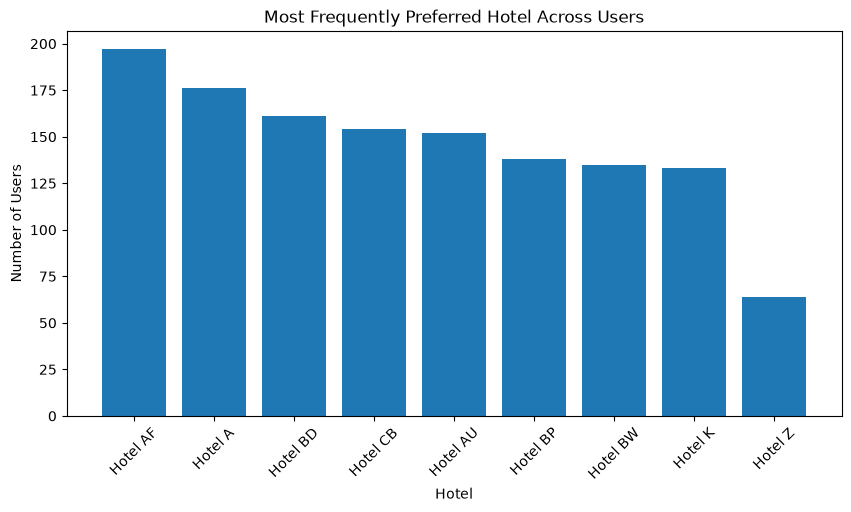

In [25]:
plt.figure(figsize=(10, 5))

plt.bar(
    preferred_hotel_distribution["hotel"],
    preferred_hotel_distribution[
        "users_with_hotel_as_top_preference"
    ]
)

plt.title("Most Frequently Preferred Hotel Across Users")
plt.xlabel("Hotel")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)

plt.show()

### Insight: Distribution of Users' Most Frequently Booked Hotels

- **Hotel AF** appears as the most frequently booked hotel for the largest number of users (**197**), followed by **Hotel A (176)** and **Hotel BD (161)**.
- **Hotel Z** appears as the top historical preference for the fewest users (**64**).
- The preferred-hotel distribution is spread across all nine hotels rather than being concentrated entirely in one property.
- This suggests that different users exhibit different historical hotel/destination preferences, which supports the possibility of personalized ranking.
- Interestingly, the hotel with the largest overall booking count is not necessarily the hotel that appears as the top preference for the largest number of individual users.
- Therefore, **global hotel popularity and individual user preference represent different behavioral signals**, both of which may be useful in a recommendation system.

## 6. User Spending and Stay Preferences

Hotel selection may be influenced not only by previous booking frequency but also by a user's historical spending and stay behavior.

This section examines user-level hotel preferences based on:

- Average hotel price
- Average stay duration
- Average total booking expenditure
- Variation in spending behavior

These behavioral features may provide additional signals for personalized hotel ranking.

In [27]:
user_hotel_behavior = (
    hotels.groupby("userCode")
    .agg(
        total_bookings=("travelCode", "count"),
        unique_hotels=("name", "nunique"),
        avg_hotel_price=("price", "mean"),
        avg_stay_days=("days", "mean"),
        avg_booking_total=("total", "mean"),
        total_hotel_spend=("total", "sum")
    )
    .reset_index()
)

display(user_hotel_behavior.head(10))



,userCode,total_bookings,unique_hotels,avg_hotel_price,avg_stay_days,avg_booking_total,total_hotel_spend
0,0,27,9,225.741481,2.629630,593.145185,16014.92
1,1,2,2,193.360000,1.000000,193.360000,386.72
2,2,36,9,210.050000,2.694444,558.003333,20088.12
3,3,60,9,217.058500,2.300000,499.568500,29974.11
4,4,56,9,214.947679,2.571429,565.316071,31657.70
5,5,13,7,209.590000,2.076923,453.542308,5896.05
6,6,23,8,220.891304,2.521739,541.562609,12455.94
7,7,14,7,172.642857,2.571429,468.804286,6563.26
8,8,52,9,224.979423,2.615385,612.737500,31862.35
9,9,32,9,195.569375,2.843750,561.572188,17970.31


### Insight: User-Level Hotel Spending and Stay Behavior

- Users exhibit differences in their historical hotel spending patterns and stay behavior.
- Average hotel price varies across users, suggesting that some users historically book relatively more expensive hotel/destination options while others tend toward lower-priced options.
- Average stay duration also varies between users, although the differences are generally smaller than the differences in hotel spending.
- Average booking total captures the combined effect of hotel price and length of stay and therefore provides an additional indicator of historical travel spending behavior.
- Total hotel expenditure varies substantially across users; however, this value is strongly influenced by the number of historical bookings and should not be treated as a direct measure of hotel preference.
- These user-level behavioral characteristics may provide useful features for personalized hotel/destination ranking.

In [28]:
display(
    user_hotel_behavior[
        [
            "avg_hotel_price",
            "avg_stay_days",
            "avg_booking_total",
            "total_hotel_spend"
        ]
    ]
    .describe()
    .round(2)
)

,avg_hotel_price,avg_stay_days,avg_booking_total,total_hotel_spend
count,1310.00,1310.00,1310.00,1310.00
mean,213.97,2.50,535.63,16599.37
std,24.74,0.31,93.56,9853.29
min,60.39,1.00,60.39,60.39
25%,201.17,2.33,489.09,8030.74
50%,213.60,2.50,533.95,16343.57
75%,228.17,2.65,580.85,24490.78
max,313.02,4.00,1251.32,40999.86


### Insight: Overall User Spending and Stay Patterns

- The average user-level hotel price is approximately **213.97**, with a median of **213.60**.
- Average hotel price varies from **60.39 to 313.02**, indicating meaningful differences in the price levels of hotels historically selected by users.
- Average stay duration is approximately **2.50 days**, with most user averages concentrated between approximately **2.33 and 2.65 days**.
- This relatively narrow range suggests that average stay duration may provide less discriminatory information than hotel price for personalization.
- Average booking expenditure is approximately **535.63**, with substantial variation across users.
- Total historical hotel expenditure varies considerably, from **60.39 to 40,999.86**, largely reflecting differences in both booking frequency and expenditure.
- Overall, historical price and booking expenditure appear to provide potentially useful behavioral signals, while stay duration appears comparatively less variable.

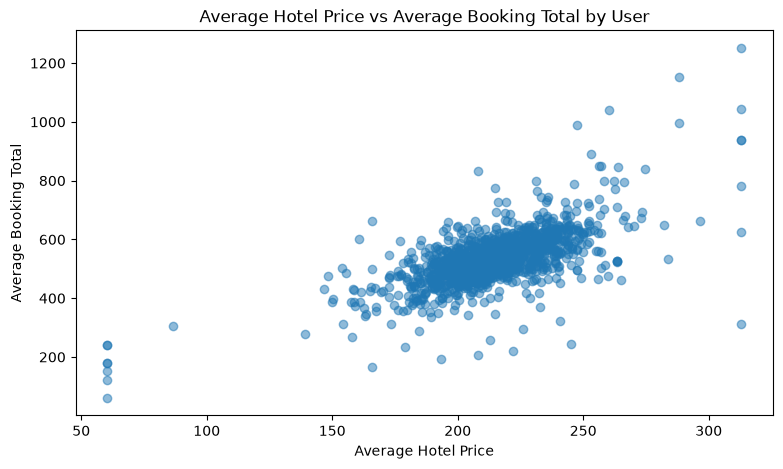

In [30]:
plt.figure(figsize=(9, 5))

plt.scatter(
    user_hotel_behavior["avg_hotel_price"],
    user_hotel_behavior["avg_booking_total"],
    alpha=0.5
)

plt.title("Average Hotel Price vs Average Booking Total by User")
plt.xlabel("Average Hotel Price")
plt.ylabel("Average Booking Total")

plt.show()

### Insight: Hotel Price and Booking Expenditure

Average booking expenditure generally reflects both the nightly hotel price and the duration of stay. Therefore, users who historically select higher-priced hotels tend to have higher booking totals, although stay duration can create additional variation.

This relationship suggests that historical hotel price and booking expenditure may help represent a user's spending preferences in the recommendation system.

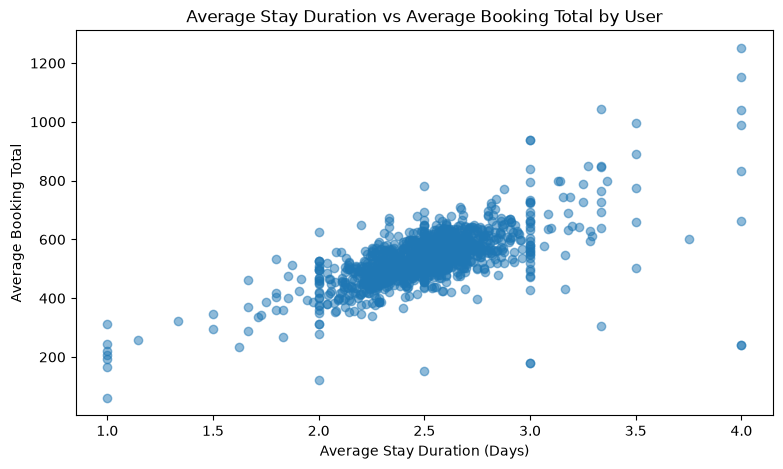

In [31]:
plt.figure(figsize=(9, 5))

plt.scatter(
    user_hotel_behavior["avg_stay_days"],
    user_hotel_behavior["avg_booking_total"],
    alpha=0.5
)

plt.title("Average Stay Duration vs Average Booking Total by User")
plt.xlabel("Average Stay Duration (Days)")
plt.ylabel("Average Booking Total")

plt.show()

### Insight: Stay Duration and Booking Expenditure

Average booking expenditure is also influenced by stay duration, since longer stays increase the total cost of a hotel booking.

However, average stay duration is concentrated around approximately 2–3 days for most users, indicating less variation than hotel-price behavior. Therefore, stay duration may be useful as a supporting feature rather than the primary recommendation signal.

## 7. User Demographics and Hotel Behavior

User demographic information may provide additional context for hotel recommendation, particularly for users with limited historical booking activity.

The user profile dataset contains age, gender, and company information. These characteristics are combined with historical hotel behavior to investigate whether different user groups exhibit differences in hotel spending and booking patterns.

Demographic variables will only be considered as supporting recommendation features if the data shows meaningful behavioral differences.

In [32]:
user_behavior_profile = users.merge(
    user_hotel_behavior,
    left_on="code",
    right_on="userCode",
    how="inner"
)

display(user_behavior_profile.head())

print("Merged users:", len(user_behavior_profile))

,code,company,name,gender,age,userCode,total_bookings,unique_hotels,avg_hotel_price,avg_stay_days,avg_booking_total,total_hotel_spend
0,0,4You,Roy Braun,male,21,0,27,9,225.741481,2.629630,593.145185,16014.92
1,1,4You,Joseph Holsten,male,37,1,2,2,193.360000,1.000000,193.360000,386.72
2,2,4You,Wilma Mcinnis,female,48,2,36,9,210.050000,2.694444,558.003333,20088.12
3,3,4You,Paula Daniel,female,23,3,60,9,217.058500,2.300000,499.568500,29974.11
4,4,4You,Patricia Carson,female,44,4,56,9,214.947679,2.571429,565.316071,31657.70


Merged users: 1310


In [36]:
gender_behavior_summary = (
    user_behavior_profile.groupby("gender")
    .agg(
        users=("code", "count"),
        avg_bookings=("total_bookings", "mean"),
        avg_unique_hotels=("unique_hotels", "mean"),
        avg_hotel_price=("avg_hotel_price", "mean"),
        avg_stay_days=("avg_stay_days", "mean"),
        avg_booking_total=("avg_booking_total", "mean")
    )
    .round(2)
    .reset_index()
)

display(gender_behavior_summary)

,gender,users,avg_bookings,avg_unique_hotels,avg_hotel_price,avg_stay_days,avg_booking_total
0,female,441,31.04,7.46,212.21,2.53,535.66
1,male,444,30.60,7.32,214.68,2.50,537.15
2,none,425,31.24,7.49,215.06,2.48,534.01


### Insight: Gender and Hotel-Booking Behavior

- Hotel-booking behavior is broadly similar across the available gender categories.
- Average booking frequency ranges only from approximately **30.60 to 31.24 bookings**, while average hotel diversity ranges from **7.32 to 7.49 hotels**.
- Average hotel price is also similar across groups, ranging from approximately **212.21 to 215.06**.
- Average stay duration remains close to **2.5 days** for all groups, and average booking totals are also very similar.
- These results do not indicate a strong descriptive relationship between gender and hotel-booking behavior in this dataset.
- Therefore, gender is unlikely to be a strong standalone recommendation signal and should not be given unnecessary importance in the recommendation strategy.

In [34]:
company_behavior_summary = (
    user_behavior_profile.groupby("company")
    .agg(
        users=("code", "count"),
        avg_bookings=("total_bookings", "mean"),
        avg_unique_hotels=("unique_hotels", "mean"),
        avg_hotel_price=("avg_hotel_price", "mean"),
        avg_stay_days=("avg_stay_days", "mean"),
        avg_booking_total=("avg_booking_total", "mean")
    )
    .round(2)
    .reset_index()
)

display(company_behavior_summary)

,company,users,avg_bookings,avg_unique_hotels,avg_hotel_price,avg_stay_days,avg_booking_total
0,4You,444,31.56,7.73,212.99,2.51,535.80
1,Acme Factory,254,30.18,6.94,202.59,2.51,509.89
2,Monsters CYA,190,31.25,7.11,236.37,2.48,585.51
3,Umbrella LTDA,190,32.78,7.23,203.32,2.51,508.76
4,Wonka Company,232,28.91,7.77,218.69,2.49,544.63


### Insight: Company and Hotel-Booking Behavior

- Hotel-booking behavior shows greater variation across companies than across gender groups.
- Users from **Monsters CYA** have the highest average hotel price at approximately **236.37** and the highest average booking total at approximately **585.51**.
- Users from **Acme Factory** and **Umbrella LTDA** show lower average hotel prices of approximately **202.59** and **203.32**, respectively.
- Average booking frequency also varies across companies, from approximately **28.91 bookings for Wonka Company** users to **32.78 bookings for Umbrella LTDA** users.
- Average stay duration remains highly consistent at approximately 2.5 days across companies.
- These descriptive differences suggest that company affiliation may contain useful information about historical travel-spending patterns.
- Company may therefore be considered as a supporting contextual feature, although its usefulness should ultimately be determined through recommendation evaluation rather than descriptive statistics alone.

In [35]:
user_behavior_profile["age_group"] = pd.cut(
    user_behavior_profile["age"],
    bins=[20, 30, 40, 50, 60, 70],
    labels=["21-30", "31-40", "41-50", "51-60", "61-70"],
    include_lowest=True
)

age_behavior_summary = (
    user_behavior_profile.groupby(
        "age_group",
        observed=True
    )
    .agg(
        users=("code", "count"),
        avg_bookings=("total_bookings", "mean"),
        avg_unique_hotels=("unique_hotels", "mean"),
        avg_hotel_price=("avg_hotel_price", "mean"),
        avg_stay_days=("avg_stay_days", "mean"),
        avg_booking_total=("avg_booking_total", "mean")
    )
    .round(2)
    .reset_index()
)

display(age_behavior_summary)

,age_group,users,avg_bookings,avg_unique_hotels,avg_hotel_price,avg_stay_days,avg_booking_total
0,21-30,281,30.69,7.39,212.84,2.50,532.38
1,31-40,317,31.08,7.38,213.45,2.52,539.14
2,41-50,298,30.29,7.45,215.52,2.51,539.22
3,51-60,272,30.86,7.39,212.59,2.52,533.86
4,61-70,142,32.79,7.58,216.78,2.45,530.06


### Insight: Age Group and Hotel-Booking Behavior

- Hotel-booking behavior is relatively consistent across age groups.
- Average booking frequency remains close to approximately **30–33 bookings**, while average hotel diversity remains between approximately **7.38 and 7.58 hotels**.
- Average hotel prices are also similar across age groups, ranging from approximately **212.59 to 216.78**.
- Users aged 61–70 show slightly higher average booking frequency and average hotel price, but the differences are relatively small.
- Average stay duration remains close to 2.5 days across all age groups.
- Overall, age does not show a strong descriptive relationship with hotel-booking behavior in this dataset.
- Therefore, historical booking behavior is likely to provide stronger personalization signals than age alone.

## 8. Recommendation EDA Summary

The exploratory analysis produced several important findings for recommendation-system design:

1. The dataset contains **40,552 hotel bookings from 1,310 users**, providing substantial historical interaction data.

2. Only **9 unique hotels** are available, and each hotel is associated with exactly **one unique destination**.

3. Because each destination contains only one hotel, the dataset cannot directly support a conventional system that recommends multiple competing hotels within a user-selected destination.

4. Users have rich booking histories, averaging approximately **31 hotel bookings per user**.

5. Users have interacted with an average of **7.42 out of 9 hotels**, and approximately **70% of users have visited 8 or 9 hotels**.

6. The user–hotel interaction matrix has only **17.52% sparsity**, meaning approximately **82.48% of possible user–hotel interactions have already occurred**.

7. Because most users have already interacted with most hotels, recommendation should not rely exclusively on identifying previously unseen hotels.

8. Repeated booking frequencies differ across users, indicating that historical booking frequency can serve as an **implicit preference signal**.

9. Global hotel popularity differs from individual user preference patterns, supporting personalized ranking rather than popularity-only recommendation.

10. Hotel price and historical booking expenditure provide additional behavioral information, while stay duration shows comparatively limited variation.

11. Gender and age groups show relatively small differences in aggregate hotel-booking behavior, while company affiliation shows greater variation in historical spending patterns.

### EDA Conclusion

Based on these findings, the recommendation problem is best framed as a **personalized hotel–destination ranking problem** rather than a conventional destination-specific hotel recommendation problem.

The model should primarily learn from historical user–hotel interactions and repeated booking behavior, with selected contextual or behavioral information used where it improves recommendation quality.

# 9. Recommendation Strategy and Model Development

Based on the exploratory analysis, the recommendation problem is formulated as a personalized hotel–destination ranking problem.

This section defines the recommendation methodology, prepares the user–hotel interaction data, develops the recommendation model, and evaluates its ability to generate personalized Top-N recommendations.

## 9.1 Recommendation System Methodology

Recommendation systems predict or rank items that are likely to be relevant to a user based on historical interactions, item characteristics, user characteristics, or a combination of these signals.

Recommendation approaches can broadly be divided into:

### 1. Popularity-Based Recommendation

Items are ranked according to their overall popularity, such as total booking frequency.

This approach is simple and useful for new users with no historical interactions, but it does not provide true personalization.

### 2. Content-Based Recommendation

Items are recommended based on similarities between item characteristics and a user's historical preferences.

This approach is useful when rich item attributes are available. However, the current hotel dataset contains relatively limited hotel-specific attributes because each hotel is associated with a single destination.

### 3. Collaborative Filtering

Collaborative filtering learns preferences from user-item interaction patterns.

Instead of requiring explicit ratings, historical booking frequency can be treated as implicit feedback. Users who demonstrate similar interaction patterns may have similar preferences.

### 4. Hybrid Recommendation

A hybrid recommendation system combines multiple signals or recommendation approaches.

For this project, historical user-hotel interactions will provide the primary personalization signal, while behavioral and contextual information can support ranking and fallback recommendations.

### Selected Problem Formulation

Based on the exploratory analysis, the recommendation task is formulated as a **personalized hotel-destination ranking problem using implicit feedback**.

Historical booking frequency represents interaction strength rather than an explicit rating. The objective is to estimate user preference for available hotel-destination options and return the highest-ranked options as Top-N recommendations.

### Implicit Feedback

The hotel dataset does not contain explicit ratings or review scores. Therefore, historical hotel bookings are treated as **implicit feedback**.

A booking indicates that a user interacted with a hotel, while repeated bookings provide a stronger interaction signal.

However, booking frequency should not be interpreted as a direct satisfaction rating. A user may repeatedly visit a destination for reasons unrelated to hotel preference. Therefore, the model estimates behavioral preference from historical interactions rather than explicit user satisfaction.

## 9.2 Explicit vs Implicit Feedback

The dataset does not contain explicit user ratings or review scores. Therefore, historical hotel bookings are treated as **implicit feedback**.

A booking represents an interaction between a user and a hotel, while repeated bookings provide a stronger interaction signal. However, booking frequency does not directly represent user satisfaction because repeated travel may also occur for business or other external reasons.

Therefore, booking frequency is interpreted as **interaction strength rather than an explicit rating**.

## 9.3 Recommendation Problem Formulation

Based on the exploratory analysis, the recommendation task is formulated as a **personalized hotel-destination ranking problem**.

For each user, the recommendation system will estimate relative preference scores for available hotel-destination combinations and rank them accordingly.

The resulting scores are used for ranking and should not be interpreted as probabilities or explicit satisfaction ratings.

## 9.4 Algorithm Selection

A **matrix-factorization approach using Truncated SVD** is selected as the primary personalized recommendation method.

The model uses the user-hotel interaction matrix, where historical booking frequency represents implicit interaction strength.

Matrix factorization learns lower-dimensional latent patterns from user-hotel interactions and uses these patterns to estimate personalized preference scores.

This approach is suitable because:

- Historical user-hotel interaction data is available.
- Users have repeated hotel bookings.
- Booking frequency provides an implicit preference signal.
- Personalized ranking is more appropriate than popularity-only recommendation.
- The method can generate preference scores for all available hotel-destination options.

Because the dataset contains only nine hotels and has a relatively dense interaction matrix, a small number of latent components will be used and the model will be evaluated against a simple baseline.

## 9.5 Evaluation Strategy

The recommendation model must be evaluated on interactions that are not used during model training.

Historical user-hotel interactions will therefore be divided into training and evaluation data. Selected interactions will be held out, and the recommender will attempt to rank the held-out relevant hotels among its Top-N recommendations.

A simple popularity-based recommender will first be established as a baseline. The personalized model will then be compared against this baseline.

This ensures that the recommendation model is evaluated on its ability to recover relevant user preferences rather than simply reproduce training interactions.

## 9.6 Evaluation Metrics

Recommendation performance will be evaluated using Top-N ranking metrics rather than regression metrics such as R², RMSE, and MAE.

The primary metrics considered are:

- **Precision@K** — the proportion of recommended items that are relevant.
- **Recall@K** — the proportion of relevant held-out items recovered within the Top-K recommendations.
- **Hit Rate@K** — the proportion of users for whom at least one relevant held-out item appears in the Top-K recommendations.

These metrics evaluate whether the recommendation system ranks relevant hotel-destination options near the top of the recommendation list.

## 9.7 Model Data Preparation

Historical hotel bookings are converted into user-hotel interaction data for recommendation modeling.

For each user-hotel pair, the total number of historical bookings is calculated. This booking frequency represents the strength of the observed interaction between the user and the hotel.

The resulting interaction dataset contains one row for each observed user-hotel combination and forms the basis for constructing the recommendation model.

In [41]:
# Create user-hotel booking frequency data

interaction_data = (
    hotels.groupby(["userCode", "name"])
    .size()
    .reset_index(name="booking_count")
)

display(interaction_data.head(15))

print("Interaction rows:", len(interaction_data))
print("Unique users:", interaction_data["userCode"].nunique())
print("Unique hotels:", interaction_data["name"].nunique())

,userCode,name,booking_count
0,0,Hotel A,3
1,0,Hotel AF,4
2,0,Hotel AU,2
3,0,Hotel BD,4
4,0,Hotel BP,1
5,0,Hotel BW,2
6,0,Hotel CB,1
7,0,Hotel K,7
8,0,Hotel Z,3
9,1,Hotel AF,1


Interaction rows: 9724
Unique users: 1310
Unique hotels: 9


### Insight: User–Hotel Interaction Data

- The original 40,552 hotel booking records are aggregated into **9,724 unique user–hotel interactions**.
- These interactions represent **1,310 users and 9 hotels**.
- Each interaction records the number of times a particular user historically booked a particular hotel.
- Repeated booking frequency therefore provides a quantitative implicit-feedback signal that can be used for personalized recommendation modeling.
- The aggregated interaction format avoids treating repeated bookings as unrelated transactions and provides a compact user–item representation for model development.

## 9.8 Interaction Strength Transformation

Raw booking frequency is useful as an implicit preference signal, but very frequent bookings should not necessarily be interpreted as proportionally stronger preference.

For example, 10 bookings do not necessarily indicate ten times the preference of one booking.

Therefore, a logarithmic transformation is applied to booking frequency:

**Interaction Strength = log(1 + Booking Count)**

This transformation preserves the ordering of interaction strength while reducing the influence of unusually high booking frequencies.

In [42]:
interaction_data["interaction_strength"] = np.log1p(
    interaction_data["booking_count"]
)

display(
    interaction_data
    .sort_values("booking_count", ascending=False)
    .head(15)
)

,userCode,name,booking_count,interaction_strength
6694,900,Hotel CB,18,2.944439
3445,454,Hotel BD,17,2.890372
8068,1104,Hotel BW,16,2.833213
1316,174,Hotel AF,16,2.833213
2618,341,Hotel A,16,2.833213
9357,1286,Hotel AU,15,2.772589
7375,1004,Hotel CB,15,2.772589
3884,516,Hotel K,15,2.772589
4527,611,Hotel A,15,2.772589
8300,1138,Hotel Z,14,2.708050


### Insight: Interaction Strength Transformation

- Raw user–hotel booking frequency ranges from **1 to 18 bookings**, with an average of approximately **4.17 bookings per observed user–hotel pair**.
- The median interaction contains 4 bookings, while 75% of observed user–hotel relationships contain 6 bookings or fewer.
- After applying the logarithmic transformation, interaction strength ranges from approximately **0.693 to 2.944**.
- The transformation reduces the numerical influence of highly repeated bookings while preserving the ordering of user–hotel interaction strength.
- For example, the maximum observed booking frequency of 18 is transformed to approximately 2.944 rather than being treated as eighteen times the strength of a single booking.
- The transformed interaction strength will therefore be used as the primary implicit-feedback value for recommendation modeling.

### Interaction Strength Summary

The distribution of raw booking frequencies and transformed interaction strengths is compared to verify the effect of the logarithmic transformation.

In [43]:
interaction_strength_summary = (
    interaction_data[
        ["booking_count", "interaction_strength"]
    ]
    .describe()
    .round(3)
)

display(interaction_strength_summary)

,booking_count,interaction_strength
count,9724.000,9724.000
mean,4.170,1.512
std,2.642,0.520
min,1.000,0.693
25%,2.000,1.099
50%,4.000,1.609
75%,6.000,1.946
max,18.000,2.944


## 9.9 Recommendation Evaluation Split

Recommendation systems require a different evaluation strategy from conventional regression models.

A **leave-one-out holdout strategy** is used for offline evaluation. For each eligible user, one historically observed hotel interaction is temporarily removed from the training data and treated as the relevant test item.

The recommendation model is trained using the user's remaining historical interactions and is then evaluated on whether it ranks the held-out hotel among its Top-N recommendations.

Only users with at least two unique hotel interactions are included in the evaluation so that every evaluated user retains historical information in the training dataset.

In [44]:
# Identify users eligible for leave-one-out evaluation

eligible_users = (
    interaction_data.groupby("userCode")["name"]
    .nunique()
)

eligible_users = eligible_users[
    eligible_users >= 2
].index

print("Total users:", interaction_data["userCode"].nunique())
print("Eligible evaluation users:", len(eligible_users))
print(
    "Excluded users with only one hotel:",
    interaction_data["userCode"].nunique() - len(eligible_users)
)

Total users: 1310
Eligible evaluation users: 1285
Excluded users with only one hotel: 25


In [45]:
# Reproducible leave-one-out holdout

RANDOM_STATE = 42

evaluation_interactions = (
    interaction_data[
        interaction_data["userCode"].isin(eligible_users)
    ]
    .groupby("userCode", group_keys=False)
    .sample(n=1, random_state=RANDOM_STATE)
    .copy()
)

display(evaluation_interactions.head(10))

print(
    "Held-out evaluation interactions:",
    len(evaluation_interactions)
)

,userCode,name,booking_count,interaction_strength
7,0,Hotel K,7,2.079442
10,1,Hotel BP,1,0.693147
11,2,Hotel A,6,1.945910
28,3,Hotel Z,2,1.098612
30,4,Hotel AF,6,1.945910
38,5,Hotel A,1,0.693147
45,6,Hotel A,4,1.609438
54,7,Hotel AU,2,1.098612
64,8,Hotel BP,4,1.609438
69,9,Hotel A,3,1.386294


Held-out evaluation interactions: 1285


In [46]:
# Create training interaction data

holdout_pairs = set(
    zip(
        evaluation_interactions["userCode"],
        evaluation_interactions["name"]
    )
)

train_interactions = interaction_data[
    ~interaction_data.apply(
        lambda row: (
            row["userCode"],
            row["name"]
        ) in holdout_pairs,
        axis=1
    )
].copy()

print("Original interactions:", len(interaction_data))
print("Training interactions:", len(train_interactions))
print("Evaluation interactions:", len(evaluation_interactions))

print(
    "Training + Evaluation:",
    len(train_interactions) + len(evaluation_interactions)
)

Original interactions: 9724
Training interactions: 8439
Evaluation interactions: 1285
Training + Evaluation: 9724


In [47]:
train_pairs = set(
    zip(
        train_interactions["userCode"],
        train_interactions["name"]
    )
)

evaluation_pairs = set(
    zip(
        evaluation_interactions["userCode"],
        evaluation_interactions["name"]
    )
)

overlap = train_pairs.intersection(evaluation_pairs)

split_validation = pd.DataFrame({
    "Check": [
        "Original interactions",
        "Training interactions",
        "Evaluation interactions",
        "Train + Evaluation",
        "Overlapping user-hotel pairs"
    ],
    "Value": [
        len(interaction_data),
        len(train_interactions),
        len(evaluation_interactions),
        len(train_interactions) + len(evaluation_interactions),
        len(overlap)
    ]
})

display(split_validation)

,Check,Value
0,Original interactions,9724
1,Training interactions,8439
2,Evaluation interactions,1285
3,Train + Evaluation,9724
4,Overlapping user-hotel pairs,0


### Insight: Recommendation Evaluation Split

- Of the **1,310 users** with hotel-booking history, **1,285 users** have interacted with at least two unique hotels and are therefore eligible for leave-one-out evaluation.
- **25 users** are excluded from offline model evaluation because removing their only observed hotel interaction would leave no historical information for generating personalized recommendations.
- One user–hotel interaction is held out for each eligible user, producing **1,285 evaluation interactions**.
- The remaining **8,439 user–hotel interactions** form the training dataset.
- Together, the training and evaluation datasets account for all **9,724 original observed user–hotel interactions**.
- There are **zero overlapping user–hotel pairs** between the training and evaluation datasets, confirming that the held-out interactions are not directly exposed to the recommendation model during training.
- This leave-one-out design enables the recommender to be evaluated on whether it can recover a historically relevant hotel from the user's remaining interaction history.

## 9.10 Popularity-Based Baseline Recommender

Before developing the personalized recommendation model, a simple popularity-based recommender is established as a baseline.

Hotel popularity is calculated using the total transformed interaction strength in the **training dataset only**.

For each user, hotels already present in that user's training history are excluded from the candidate set. The remaining hotels are ranked according to global popularity.

The popularity baseline does not use personalized preference patterns. Therefore, it provides a reference point for determining whether the personalized recommendation model adds value beyond recommending generally popular hotels.

In [48]:
hotel_popularity = (
    train_interactions
    .groupby("name")
    .agg(
        users=("userCode", "nunique"),
        total_bookings=("booking_count", "sum"),
        popularity_score=("interaction_strength", "sum")
    )
    .sort_values(
        "popularity_score",
        ascending=False
    )
    .reset_index()
)

display(hotel_popularity)

,name,users,total_bookings,popularity_score
0,Hotel CB,1026,4454,1585.183145
1,Hotel K,986,4423,1549.399051
2,Hotel AF,988,4152,1503.350835
3,Hotel BD,989,4164,1501.779247
4,Hotel AU,1008,3977,1483.642741
5,Hotel BP,979,3938,1452.756233
6,Hotel Z,951,3638,1379.577549
7,Hotel BW,856,3751,1332.031420
8,Hotel A,656,2967,1034.499276


### Insight: Training-Data Hotel Popularity

- Based only on the training interactions, **Hotel CB** has the highest transformed popularity score, followed by **Hotel K** and **Hotel AF**.
- Popularity is calculated exclusively from training data so that held-out evaluation interactions do not influence the baseline recommender.
- The popularity ranking differs slightly from the earlier full-dataset booking ranking because one interaction has been removed for each eligible evaluation user.
- This popularity model provides a non-personalized benchmark against which the personalized recommendation model can be evaluated.

In [49]:
TOP_K = 3

popularity_ranking = hotel_popularity["name"].tolist()


def recommend_popular_hotels(user_id, top_k=TOP_K):
    """
    Recommend globally popular hotels that are not present
    in the user's training interactions.
    """

    seen_hotels = set(
        train_interactions.loc[
            train_interactions["userCode"] == user_id,
            "name"
        ]
    )

    candidate_hotels = [
        hotel
        for hotel in popularity_ranking
        if hotel not in seen_hotels
    ]

    return candidate_hotels[:top_k]

In [50]:
sample_users = evaluation_interactions[
    "userCode"
].head(10).tolist()

baseline_examples = []

for user_id in sample_users:

    actual_hotel = evaluation_interactions.loc[
        evaluation_interactions["userCode"] == user_id,
        "name"
    ].iloc[0]

    recommendations = recommend_popular_hotels(
        user_id,
        TOP_K
    )

    baseline_examples.append({
        "userCode": user_id,
        "held_out_hotel": actual_hotel,
        "recommendations": recommendations,
        "hit_at_3": actual_hotel in recommendations
    })

baseline_examples_df = pd.DataFrame(
    baseline_examples
)

display(baseline_examples_df)

,userCode,held_out_hotel,recommendations,hit_at_3
0,0,Hotel K,[Hotel K],True
1,1,Hotel BP,"[Hotel CB, Hotel K, Hotel BD]",False
2,2,Hotel A,[Hotel A],True
3,3,Hotel Z,[Hotel Z],True
4,4,Hotel AF,[Hotel AF],True
5,5,Hotel A,"[Hotel AU, Hotel BP, Hotel A]",True
6,6,Hotel A,"[Hotel Z, Hotel A]",True
7,7,Hotel AU,"[Hotel K, Hotel AU, Hotel A]",True
8,8,Hotel BP,[Hotel BP],True
9,9,Hotel A,[Hotel A],True


In [51]:
baseline_results = []

for user_id in evaluation_interactions["userCode"]:

    actual_hotel = evaluation_interactions.loc[
        evaluation_interactions["userCode"] == user_id,
        "name"
    ].iloc[0]

    recommendations = recommend_popular_hotels(
        user_id,
        TOP_K
    )

    hit = int(actual_hotel in recommendations)

    baseline_results.append({
        "userCode": user_id,
        "held_out_hotel": actual_hotel,
        "recommendations": recommendations,
        "hit": hit
    })

baseline_results_df = pd.DataFrame(
    baseline_results
)

display(baseline_results_df.head(10))

,userCode,held_out_hotel,recommendations,hit
0,0,Hotel K,[Hotel K],1
1,1,Hotel BP,"[Hotel CB, Hotel K, Hotel BD]",0
2,2,Hotel A,[Hotel A],1
3,3,Hotel Z,[Hotel Z],1
4,4,Hotel AF,[Hotel AF],1
5,5,Hotel A,"[Hotel AU, Hotel BP, Hotel A]",1
6,6,Hotel A,"[Hotel Z, Hotel A]",1
7,7,Hotel AU,"[Hotel K, Hotel AU, Hotel A]",1
8,8,Hotel BP,[Hotel BP],1
9,9,Hotel A,[Hotel A],1


In [52]:
baseline_hit_rate = (
    baseline_results_df["hit"].mean()
)

baseline_recall_at_k = baseline_hit_rate

baseline_precision_at_k = (
    baseline_results_df["hit"].sum()
    /
    baseline_results_df[
        "recommendations"
    ].apply(len).sum()
)

baseline_metrics = pd.DataFrame({
    "Metric": [
        f"Hit Rate@{TOP_K}",
        f"Recall@{TOP_K}",
        f"Precision@{TOP_K}"
    ],
    "Value": [
        baseline_hit_rate,
        baseline_recall_at_k,
        baseline_precision_at_k
    ]
})

display(
    baseline_metrics.assign(
        Value=lambda x: x["Value"].round(4)
    )
)

,Metric,Value
0,Hit Rate@3,0.9486
1,Recall@3,0.9486
2,Precision@3,0.4765


### Insight: Popularity Baseline Performance

- The popularity baseline achieves a **Hit Rate@3 and Recall@3 of 0.9486**, while Precision@3 is approximately **0.4765**.
- Although the Hit Rate appears very high, it must be interpreted in the context of the unusually small and dense hotel catalog.
- Of the 1,285 evaluated users, **376 users have only one candidate hotel** and **545 users have only two candidate hotels** after their training interactions are excluded.
- Therefore, approximately **71.7% of evaluated users have no more than two candidate hotels**, making a Top-3 hit effectively guaranteed for those users regardless of ranking quality.
- The high baseline Hit Rate therefore reflects both hotel popularity and the restricted candidate space rather than purely strong recommendation performance.
- Consequently, the personalized model should be compared against the baseline using exactly the same candidate sets, and additional ranking diagnostics should be considered when interpreting performance.

In [53]:
candidate_counts = []

all_hotels = set(
    interaction_data["name"].unique()
)

for user_id in evaluation_interactions["userCode"]:

    seen_hotels = set(
        train_interactions.loc[
            train_interactions["userCode"] == user_id,
            "name"
        ]
    )

    candidate_counts.append(
        len(all_hotels - seen_hotels)
    )

candidate_summary = (
    pd.Series(
        candidate_counts,
        name="candidate_hotels"
    )
    .describe()
    .round(2)
)

display(candidate_summary.to_frame())

,candidate_hotels
count,1285.00
mean,2.45
std,1.67
min,1.00
25%,1.00
50%,2.00
75%,3.00
max,8.00


In [54]:
candidate_distribution = (
    pd.Series(candidate_counts)
    .value_counts()
    .sort_index()
    .rename_axis("candidate_hotels")
    .reset_index(name="users")
)

display(candidate_distribution)

,candidate_hotels,users
0,1,376
1,2,545
2,3,126
3,4,76
4,5,58
5,6,43
6,7,33
7,8,28


### Baseline Evaluation at Multiple Ranking Depths

Because the hotel catalog contains only nine items and many users have small candidate sets, evaluation is performed at multiple ranking depths.

In particular, **Hit Rate@1** provides a stricter measure of whether the held-out hotel is ranked as the user's highest-priority recommendation, while Hit Rate@2 and Hit Rate@3 provide progressively broader measures of recommendation recovery.

In [55]:
def evaluate_popularity_at_k(k):
    results = []

    for user_id in evaluation_interactions["userCode"]:

        actual_hotel = evaluation_interactions.loc[
            evaluation_interactions["userCode"] == user_id,
            "name"
        ].iloc[0]

        recommendations = recommend_popular_hotels(
            user_id,
            top_k=k
        )

        hit = int(actual_hotel in recommendations)

        results.append({
            "userCode": user_id,
            "held_out_hotel": actual_hotel,
            "recommendations": recommendations,
            "hit": hit
        })

    results_df = pd.DataFrame(results)

    hit_rate = results_df["hit"].mean()

    precision = (
        results_df["hit"].sum()
        / results_df["recommendations"].apply(len).sum()
    )

    return {
        "K": k,
        "Hit_Rate": hit_rate,
        "Recall": hit_rate,
        "Precision": precision
    }


baseline_multi_k = pd.DataFrame(
    [
        evaluate_popularity_at_k(k)
        for k in [1, 2, 3]
    ]
)

display(
    baseline_multi_k.round(4)
)

,K,Hit_Rate,Recall,Precision
0,1,0.7377,0.7377,0.7377
1,2,0.8949,0.8949,0.5242
2,3,0.9486,0.9486,0.4765


### Insight: Popularity Baseline Across Ranking Depths

- The popularity baseline achieves a **Hit Rate@1 of 0.7377**, meaning that the held-out hotel is ranked as the first recommendation for approximately 73.77% of evaluated users.
- Hit Rate increases to **0.8949 at K=2** and **0.9486 at K=3**, as progressively more candidate hotels are included in the recommendation list.
- Recall follows the same values as Hit Rate because each evaluated user has exactly one held-out relevant hotel.
- Precision decreases from **0.7377 at K=1** to **0.4765 at K=3**, which is expected as larger recommendation lists contain more items while only one held-out item is considered relevant.
- Because many users have very small candidate sets, Hit Rate@2 and Hit Rate@3 are relatively easy to achieve.
- Therefore, **Hit Rate@1 provides the stricter and more informative baseline metric** for comparing personalized recommendation models in this dataset.

## 9.11 Personalized Matrix-Factorization Recommendation Model

A personalized recommendation model is developed using **Truncated Singular Value Decomposition (SVD)**.

The training user–hotel interaction matrix contains transformed implicit-feedback values representing historical booking strength.

Truncated SVD decomposes this matrix into a smaller set of latent factors that capture underlying patterns in user–hotel interactions. These latent representations are then used to reconstruct estimated preference scores for user–hotel combinations.

Hotels already present in a user's training history are excluded from recommendation candidates, and the remaining hotels are ranked according to their reconstructed preference scores.

In [56]:
train_matrix = (
    train_interactions
    .pivot(
        index="userCode",
        columns="name",
        values="interaction_strength"
    )
    .fillna(0)
)

display(train_matrix.head())

print("Training matrix shape:", train_matrix.shape)

name,Hotel A,Hotel AF,Hotel AU,Hotel BD,Hotel BP,Hotel BW,Hotel CB,Hotel K,Hotel Z
userCode,,,,,,,,,
0,1.386294,1.609438,1.098612,1.609438,0.693147,1.098612,0.693147,0.000000,1.386294
1,0.000000,0.693147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,1.098612,1.386294,1.098612,1.098612,2.079442,1.386294,1.791759,1.945910
3,2.397895,1.945910,2.079442,2.484907,1.098612,2.302585,2.079442,1.945910,0.000000
4,2.079442,0.000000,2.079442,1.791759,1.386294,1.945910,2.484907,2.079442,1.609438


Training matrix shape: (1310, 9)


In [57]:
matrix_summary = pd.DataFrame({
    "Metric": [
        "Users",
        "Hotels",
        "Matrix cells",
        "Non-zero training interactions",
        "Zero cells"
    ],
    "Value": [
        train_matrix.shape[0],
        train_matrix.shape[1],
        train_matrix.size,
        (train_matrix > 0).sum().sum(),
        (train_matrix == 0).sum().sum()
    ]
})

display(matrix_summary)

,Metric,Value
0,Users,1310
1,Hotels,9
2,Matrix cells,11790
3,Non-zero training interactions,8439
4,Zero cells,3351


### Insight: Training User–Hotel Matrix

- The recommendation training matrix contains **1,310 users and 9 hotels**, producing **11,790 possible user–hotel combinations**.
- **8,439 cells contain observed training interactions**, while **3,351 cells contain zero interaction values**.
- The zero-valued cells include both historically unobserved hotel interactions and the interactions deliberately removed for offline evaluation.
- The matrix therefore provides the structured user–item representation required for matrix-factorization modeling.
- All 1,310 users remain in the training matrix because the 25 users excluded from leave-one-out evaluation retain their original interactions for model training.

## 9.12 SVD Hyperparameter Tuning Strategy

The number of latent components (`n_components`) is the primary hyperparameter evaluated for the Truncated SVD recommendation model.

Because the dataset contains only nine hotels, a small range of latent dimensions is considered.

To avoid selecting model hyperparameters using the same users employed for final evaluation, eligible evaluation users are divided into:

- **Validation users** — used to compare SVD configurations and select the best number of latent components.
- **Final test users** — reserved for the final comparison between the selected SVD model and the popularity baseline.

This provides a clearer separation between model selection and final performance evaluation.

In [58]:
from sklearn.model_selection import train_test_split

evaluation_user_ids = (
    evaluation_interactions["userCode"]
    .unique()
)

validation_users, test_users = train_test_split(
    evaluation_user_ids,
    test_size=0.30,
    random_state=42
)

print("Eligible evaluation users:", len(evaluation_user_ids))
print("Validation users:", len(validation_users))
print("Final test users:", len(test_users))
print(
    "Validation + Test:",
    len(validation_users) + len(test_users)
)

Eligible evaluation users: 1285
Validation users: 899
Final test users: 386
Validation + Test: 1285


### Insight: Validation and Final-Test User Split

- The **1,285 eligible evaluation users** are divided into **899 validation users** and **386 final-test users**.
- Validation users are used exclusively for comparing SVD hyperparameter configurations.
- Final-test users are reserved for evaluating the selected recommendation model after hyperparameter selection.
- This separation prevents the final-test users from directly influencing the selection of the number of latent components.

In [59]:
from sklearn.decomposition import TruncatedSVD

svd_test = TruncatedSVD(
    n_components=3,
    random_state=42
)

user_factors_test = svd_test.fit_transform(
    train_matrix
)

reconstructed_matrix_test = (
    user_factors_test
    @ svd_test.components_
)

print(
    "Original matrix shape:",
    train_matrix.shape
)

print(
    "User latent factors shape:",
    user_factors_test.shape
)

print(
    "Hotel latent factors shape:",
    svd_test.components_.shape
)

print(
    "Reconstructed matrix shape:",
    reconstructed_matrix_test.shape
)

print(
    "Explained variance ratio:",
    round(
        svd_test.explained_variance_ratio_.sum(),
        4
    )
)

Original matrix shape: (1310, 9)
User latent factors shape: (1310, 3)
Hotel latent factors shape: (3, 9)
Reconstructed matrix shape: (1310, 9)
Explained variance ratio: 0.5743


### Insight: Initial SVD Decomposition

- With `n_components=3`, the original **1,310 × 9** user–hotel interaction matrix is represented using three latent dimensions.
- Each of the 1,310 users receives a three-dimensional latent representation, while the nine hotels are represented across the same three latent dimensions.
- Multiplying the learned user and hotel latent representations reconstructs a **1,310 × 9 preference-score matrix**.
- The three-component model explains approximately **57.43% of the variance** in the training interaction matrix.
- Explained variance measures how much of the interaction structure is captured by the latent representation; it is not a recommendation-accuracy metric.
- Recommendation quality must therefore be assessed using ranking metrics on held-out interactions.

In [60]:
svd_score_matrix_test = pd.DataFrame(
    reconstructed_matrix_test,
    index=train_matrix.index,
    columns=train_matrix.columns
)

display(
    svd_score_matrix_test.head()
)

name,Hotel A,Hotel AF,Hotel AU,Hotel BD,Hotel BP,Hotel BW,Hotel CB,Hotel K,Hotel Z
userCode,,,,,,,,,
0,1.094938,1.062094,1.109874,1.137825,1.070774,0.665112,1.170606,1.074602,0.967374
1,0.011858,0.088210,0.099037,0.085992,0.090885,0.059619,0.084975,0.079468,0.103284
2,-0.128264,1.462411,1.333573,1.299339,1.372510,2.037429,1.391352,1.566860,1.485481
3,2.649226,1.714167,1.308571,1.821021,1.534638,2.269206,2.065608,2.193012,0.917814
4,2.022333,1.686967,1.512773,1.776502,1.598406,1.731728,1.925224,1.935934,1.239175


### Insight: Reconstructed Preference Scores

- SVD produces an estimated preference score for every user–hotel combination.
- These reconstructed values represent relative latent preference signals and are used to rank candidate hotels.
- Higher reconstructed scores indicate stronger modeled preference relative to other candidate hotels for the same user.
- The scores should not be interpreted as probabilities, ratings, or direct measures of customer satisfaction.
- Negative reconstructed values are mathematically valid and simply represent lower relative scores within the latent-factor representation.

## 9.13 SVD Hyperparameter Tuning

The number of latent components controls the dimensionality of the user and hotel representations learned by Truncated SVD.

Because the catalog contains only nine hotels, candidate values from **2 to 8 latent components** are evaluated.

Each SVD configuration is trained on the same interaction matrix and evaluated using the same validation users and held-out interactions.

Model selection primarily considers **Hit Rate@1**, since this is the strictest ranking metric for the small and dense hotel catalog. Hit Rate@2 and Hit Rate@3 are retained as supporting metrics.

Explained variance is also recorded to understand how much of the interaction structure is captured by each configuration, but recommendation performance rather than explained variance determines the final model selection.

In [61]:
def recommend_svd_hotels(
    user_id,
    score_matrix,
    top_k=3
):
    """
    Rank hotels using reconstructed SVD preference scores,
    excluding hotels present in the user's training history.
    """

    seen_hotels = set(
        train_interactions.loc[
            train_interactions["userCode"] == user_id,
            "name"
        ]
    )

    candidate_scores = (
        score_matrix
        .loc[user_id]
        .drop(
            labels=list(seen_hotels),
            errors="ignore"
        )
        .sort_values(ascending=False)
    )

    return candidate_scores.head(top_k).index.tolist()

In [62]:
def evaluate_svd_model(
    score_matrix,
    user_ids,
    k
):
    """
    Evaluate SVD recommendations for a specified
    group of users using leave-one-out interactions.
    """

    hits = 0
    total_recommendations = 0

    user_ids = set(user_ids)

    eval_subset = evaluation_interactions[
        evaluation_interactions["userCode"].isin(user_ids)
    ]

    for _, row in eval_subset.iterrows():

        user_id = row["userCode"]
        actual_hotel = row["name"]

        recommendations = recommend_svd_hotels(
            user_id,
            score_matrix,
            top_k=k
        )

        if actual_hotel in recommendations:
            hits += 1

        total_recommendations += len(
            recommendations
        )

    total_users = len(eval_subset)

    hit_rate = hits / total_users

    # One held-out relevant hotel per user
    recall = hit_rate

    precision = (
        hits / total_recommendations
        if total_recommendations > 0
        else 0
    )

    return {
        "Hit_Rate": hit_rate,
        "Recall": recall,
        "Precision": precision
    }

In [63]:
component_values = [2, 3, 4, 5, 6, 7, 8]

svd_tuning_results = []

for n_components in component_values:

    svd_model = TruncatedSVD(
        n_components=n_components,
        random_state=42
    )

    user_factors = svd_model.fit_transform(
        train_matrix
    )

    reconstructed_matrix = (
        user_factors
        @ svd_model.components_
    )

    score_matrix = pd.DataFrame(
        reconstructed_matrix,
        index=train_matrix.index,
        columns=train_matrix.columns
    )

    metrics_at_1 = evaluate_svd_model(
        score_matrix,
        validation_users,
        k=1
    )

    metrics_at_2 = evaluate_svd_model(
        score_matrix,
        validation_users,
        k=2
    )

    metrics_at_3 = evaluate_svd_model(
        score_matrix,
        validation_users,
        k=3
    )

    svd_tuning_results.append({
        "n_components": n_components,
        "explained_variance": (
            svd_model
            .explained_variance_ratio_
            .sum()
        ),
        "Hit_Rate@1": metrics_at_1["Hit_Rate"],
        "Hit_Rate@2": metrics_at_2["Hit_Rate"],
        "Hit_Rate@3": metrics_at_3["Hit_Rate"],
        "Precision@1": metrics_at_1["Precision"],
        "Precision@2": metrics_at_2["Precision"],
        "Precision@3": metrics_at_3["Precision"]
    })


svd_tuning_df = pd.DataFrame(
    svd_tuning_results
)

display(
    svd_tuning_df.round(4)
)

,n_components,explained_variance,Hit_Rate@1,Hit_Rate@2,Hit_Rate@3,Precision@1,Precision@2,Precision@3
0,2,0.4760,0.7497,0.8888,0.9455,0.7497,0.5215,0.4754
1,3,0.5743,0.7308,0.8776,0.9455,0.7308,0.5150,0.4754
2,4,0.6541,0.7286,0.8732,0.9366,0.7286,0.5124,0.4709
3,5,0.7332,0.6997,0.8732,0.9299,0.6997,0.5124,0.4676
4,6,0.8050,0.6685,0.8654,0.9221,0.6685,0.5078,0.4636
5,7,0.8756,0.6485,0.8665,0.9299,0.6485,0.5085,0.4676
6,8,0.9379,0.6218,0.8643,0.9310,0.6218,0.5072,0.4681


In [64]:
svd_tuning_ranked = (
    svd_tuning_df
    .sort_values(
        by=[
            "Hit_Rate@1",
            "Hit_Rate@2",
            "Hit_Rate@3"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    svd_tuning_ranked.round(4)
)

,n_components,explained_variance,Hit_Rate@1,Hit_Rate@2,Hit_Rate@3,Precision@1,Precision@2,Precision@3
0,2,0.4760,0.7497,0.8888,0.9455,0.7497,0.5215,0.4754
1,3,0.5743,0.7308,0.8776,0.9455,0.7308,0.5150,0.4754
2,4,0.6541,0.7286,0.8732,0.9366,0.7286,0.5124,0.4709
3,5,0.7332,0.6997,0.8732,0.9299,0.6997,0.5124,0.4676
4,6,0.8050,0.6685,0.8654,0.9221,0.6685,0.5078,0.4636
5,7,0.8756,0.6485,0.8665,0.9299,0.6485,0.5085,0.4676
6,8,0.9379,0.6218,0.8643,0.9310,0.6218,0.5072,0.4681


In [65]:
best_n_components = int(
    svd_tuning_ranked.loc[
        0,
        "n_components"
    ]
)

print(
    "Selected n_components:",
    best_n_components
)

Selected n_components: 2


### Insight: SVD Hyperparameter Tuning

- Seven SVD configurations were evaluated using **2 to 8 latent components** on the validation-user subset.
- The **2-component SVD model achieved the highest Hit Rate@1 of 0.7497**, making it the strongest configuration under the primary model-selection criterion.
- It also achieved a Hit Rate@2 of **0.8888** and Hit Rate@3 of **0.9455**.
- Increasing the number of latent components substantially increased explained variance, from **47.60% with 2 components to 93.79% with 8 components**.
- However, higher explained variance did not translate into better recommendation ranking. Hit Rate@1 generally declined as additional latent components were introduced.
- This demonstrates that maximizing reconstruction quality is not equivalent to maximizing recommendation quality.
- Based on the predefined ranking criteria, **n_components = 2 is selected as the final SVD hyperparameter configuration**.

## 9.14 Final SVD Model Training

Based on validation-set hyperparameter tuning, **2 latent components** are selected for the final Truncated SVD recommendation model.

The selected model is trained using the complete recommendation training interaction matrix. The resulting latent representations are used to reconstruct personalized preference scores for all user–hotel combinations.

The final-test users remain reserved for unbiased comparison between the selected personalized SVD model and the popularity-based baseline.

In [66]:
final_svd_model = TruncatedSVD(
    n_components=best_n_components,
    random_state=42
)

final_user_factors = final_svd_model.fit_transform(
    train_matrix
)

final_reconstructed_matrix = (
    final_user_factors
    @ final_svd_model.components_
)

final_svd_scores = pd.DataFrame(
    final_reconstructed_matrix,
    index=train_matrix.index,
    columns=train_matrix.columns
)

print(
    "Selected n_components:",
    final_svd_model.n_components
)

print(
    "Final explained variance:",
    round(
        final_svd_model.explained_variance_ratio_.sum(),
        4
    )
)

print(
    "Final score matrix shape:",
    final_svd_scores.shape
)

Selected n_components: 2
Final explained variance: 0.476
Final score matrix shape: (1310, 9)


## 9.15 Final Recommendation Model Evaluation

After hyperparameter selection, the personalized SVD recommender is evaluated on the reserved final-test users.

Its performance is compared against the popularity-based baseline using the same held-out interactions, candidate restrictions, and ranking depths.

The comparison is performed at **K = 1, 2, and 3**, with particular emphasis on Hit Rate@1 because it represents the strictest ranking criterion for the small hotel catalog.

In [67]:
def evaluate_popularity_users(
    user_ids,
    k
):
    hits = 0
    total_recommendations = 0

    user_ids = set(user_ids)

    eval_subset = evaluation_interactions[
        evaluation_interactions["userCode"].isin(user_ids)
    ]

    for _, row in eval_subset.iterrows():

        user_id = row["userCode"]
        actual_hotel = row["name"]

        recommendations = recommend_popular_hotels(
            user_id,
            top_k=k
        )

        if actual_hotel in recommendations:
            hits += 1

        total_recommendations += len(
            recommendations
        )

    total_users = len(eval_subset)

    hit_rate = hits / total_users

    precision = (
        hits / total_recommendations
        if total_recommendations > 0
        else 0
    )

    return {
        "Hit_Rate": hit_rate,
        "Recall": hit_rate,
        "Precision": precision
    }

In [68]:
final_comparison = []

for k in [1, 2, 3]:

    popularity_metrics = evaluate_popularity_users(
        test_users,
        k
    )

    svd_metrics = evaluate_svd_model(
        final_svd_scores,
        test_users,
        k
    )

    final_comparison.append({
        "Model": "Popularity Baseline",
        "K": k,
        "Hit_Rate": popularity_metrics["Hit_Rate"],
        "Recall": popularity_metrics["Recall"],
        "Precision": popularity_metrics["Precision"]
    })

    final_comparison.append({
        "Model": "Personalized SVD",
        "K": k,
        "Hit_Rate": svd_metrics["Hit_Rate"],
        "Recall": svd_metrics["Recall"],
        "Precision": svd_metrics["Precision"]
    })


final_comparison_df = pd.DataFrame(
    final_comparison
)

display(
    final_comparison_df.round(4)
)

,Model,K,Hit_Rate,Recall,Precision
0,Popularity Baseline,1,0.7280,0.7280,0.7280
1,Personalized SVD,1,0.7383,0.7383,0.7383
2,Popularity Baseline,2,0.8938,0.8938,0.5211
3,Personalized SVD,2,0.8834,0.8834,0.5151
4,Popularity Baseline,3,0.9482,0.9482,0.4753
5,Personalized SVD,3,0.9482,0.9482,0.4753


### Insight: Final SVD vs Popularity Baseline

- The tuned **2-component SVD model** achieves a final-test **Hit Rate@1 of 0.7383**, compared with **0.7280** for the popularity baseline.
- This represents an absolute improvement of approximately **1.04 percentage points** at the strictest ranking depth.
- At K=2, the popularity baseline performs slightly better, achieving **0.8938** compared with **0.8834** for SVD.
- At K=3, both models achieve the same Hit Rate of **0.9482**.
- The results indicate that personalization provides a **small improvement in first-choice ranking**, but does not consistently outperform the popularity baseline at larger recommendation depths.
- This limited improvement is consistent with the structure of the dataset: the hotel catalog contains only nine hotels and users have historically interacted with a large proportion of the available catalog.
- Therefore, the SVD model demonstrates personalized ranking capability, but the dataset provides limited opportunity for strong differentiation from a popularity-based recommender.

In [69]:
comparison_pivot = (
    final_comparison_df
    .pivot(
        index="K",
        columns="Model",
        values="Hit_Rate"
    )
)

comparison_pivot[
    "SVD_minus_Popularity"
] = (
    comparison_pivot["Personalized SVD"]
    -
    comparison_pivot["Popularity Baseline"]
)

display(
    comparison_pivot.round(4)
)

Model,Personalized SVD,Popularity Baseline,SVD_minus_Popularity
K,,,
1,0.7383,0.7280,0.0104
2,0.8834,0.8938,-0.0104
3,0.9482,0.9482,0.0000


### Insight: Ranking Precision

- Precision@1 is highest for the personalized SVD model at **0.7383**, consistent with its superior first-position Hit Rate.
- Precision decreases as recommendation-list size increases because each evaluated user has only one held-out relevant hotel.
- Since the evaluation uses one relevant item per user, Hit Rate@1 and Precision@1 are identical.
- The precision results reinforce the conclusion that SVD's main advantage is a modest improvement in ranking the relevant hotel in the first position rather than a broad improvement across larger recommendation lists.

In [70]:
sample_test_users = list(test_users[:10])

recommendation_examples = []

for user_id in sample_test_users:

    actual_hotel = evaluation_interactions.loc[
        evaluation_interactions["userCode"] == user_id,
        "name"
    ].iloc[0]

    svd_recommendations = recommend_svd_hotels(
        user_id,
        final_svd_scores,
        top_k=3
    )

    popularity_recommendations = (
        recommend_popular_hotels(
            user_id,
            top_k=3
        )
    )

    recommendation_examples.append({
        "userCode": user_id,
        "held_out_hotel": actual_hotel,
        "SVD_recommendations": svd_recommendations,
        "Popularity_recommendations": popularity_recommendations,
        "SVD_hit": actual_hotel in svd_recommendations
    })


recommendation_examples_df = pd.DataFrame(
    recommendation_examples
)

display(recommendation_examples_df)

,userCode,held_out_hotel,SVD_recommendations,Popularity_recommendations,SVD_hit
0,1297,Hotel BD,"[Hotel AF, Hotel BD, Hotel A]","[Hotel AF, Hotel BD, Hotel A]",True
1,754,Hotel CB,"[Hotel CB, Hotel AF, Hotel AU]","[Hotel CB, Hotel AF, Hotel AU]",True
2,642,Hotel Z,"[Hotel Z, Hotel BW]","[Hotel Z, Hotel BW]",True
3,934,Hotel AF,"[Hotel CB, Hotel K, Hotel AF]","[Hotel CB, Hotel K, Hotel AF]",True
4,1255,Hotel Z,"[Hotel Z, Hotel A]","[Hotel Z, Hotel A]",True
5,1247,Hotel BP,"[Hotel Z, Hotel AF, Hotel K]","[Hotel CB, Hotel K, Hotel AF]",False
6,251,Hotel BW,[Hotel BW],[Hotel BW],True
7,610,Hotel Z,"[Hotel BD, Hotel Z, Hotel BW]","[Hotel BD, Hotel Z, Hotel BW]",True
8,304,Hotel Z,[Hotel Z],[Hotel Z],True
9,435,Hotel CB,[Hotel CB],[Hotel CB],True


### Insight: Ranking Precision

- Precision@1 is highest for the personalized SVD model at **0.7383**, consistent with its superior first-position Hit Rate.
- Precision decreases as recommendation-list size increases because each evaluated user has only one held-out relevant hotel.
- Since the evaluation uses one relevant item per user, Hit Rate@1 and Precision@1 are identical.
- The precision results reinforce the conclusion that SVD's main advantage is a modest improvement in ranking the relevant hotel in the first position rather than a broad improvement across larger recommendation lists.

## 9.16 Final Recommendation Model Selection

The **2-component Truncated SVD model** is selected as the personalized hotel recommendation model.

The decision is based primarily on validation-driven hyperparameter selection and its superior final-test Hit Rate@1 compared with the popularity baseline.

On the reserved final-test users:

- **SVD Hit Rate@1:** 0.7383
- **Popularity Hit Rate@1:** 0.7280
- **Absolute improvement:** approximately 1.04 percentage points

Although SVD does not consistently outperform popularity at larger ranking depths, it provides personalized user-specific rankings derived from historical interaction patterns.

Given the small nine-hotel catalog and high historical interaction coverage, only modest improvement over a strong popularity baseline is expected.

For deployment, the personalized SVD model will be used for users with suitable historical interaction information, while the popularity-based recommender can serve as a fallback strategy for users without sufficient recommendation history.

## 9.17 Production Recommendation Function

The final recommendation layer combines the personalized SVD model with a popularity-based fallback strategy.

For users with historical recommendation data, hotels are ranked using personalized SVD preference scores.

For users without usable interaction history, the globally popular hotel ranking is used as a fallback.

The recommendation output also includes hotel metadata such as destination and average hotel price so that the results can later be integrated into the Travel Analytics application.

In [71]:
hotel_metadata = (
    hotels.groupby("name")
    .agg(
        place=("place", "first"),
        average_price=("price", "mean"),
        average_stay_days=("days", "mean"),
        total_bookings=("travelCode", "count")
    )
    .reset_index()
)

display(hotel_metadata)

,name,place,average_price,average_stay_days,total_bookings
0,Hotel A,Florianopolis (SC),313.02,2.483183,3330
1,Hotel AF,Sao Paulo (SP),139.10,2.511599,4828
2,Hotel AU,Recife (PE),312.83,2.520931,4467
3,Hotel BD,Natal (RN),242.88,2.499068,4829
4,Hotel BP,Brasilia (DF),247.62,2.486365,4437
5,Hotel BW,Campo Grande (MS),60.39,2.495500,4333
6,Hotel CB,Rio de Janeiro (RJ),165.99,2.485981,5029
7,Hotel K,Salvador (BH),263.41,2.516490,5094
8,Hotel Z,Aracaju (SE),208.04,2.491558,4205


In [72]:
def get_hotel_recommendations(
    user_id,
    top_n=3
):
    """
    Generate personalized hotel recommendations.

    Known users:
        Use SVD preference scores and exclude hotels already
        present in the user's training interaction history.

    New / unknown users:
        Use the popularity-based fallback ranking.
    """

    all_hotels = set(
        final_svd_scores.columns
    )

    # --------------------------------------------------------
    # CASE 1: Known user
    # --------------------------------------------------------
    if user_id in final_svd_scores.index:

        seen_hotels = set(
            train_interactions.loc[
                train_interactions["userCode"] == user_id,
                "name"
            ]
        )

        candidate_hotels = list(
            all_hotels - seen_hotels
        )

        # If unseen candidates exist, rank them using SVD
        if candidate_hotels:

            user_scores = (
                final_svd_scores
                .loc[user_id, candidate_hotels]
                .sort_values(ascending=False)
            )

            ranked_hotels = (
                user_scores
                .head(top_n)
                .reset_index()
            )

            ranked_hotels.columns = [
                "name",
                "recommendation_score"
            ]

            recommendation_type = "Personalized SVD"

        else:
            # User has already interacted with every hotel
            ranked_hotels = pd.DataFrame({
                "name": popularity_ranking[:top_n]
            })

            ranked_hotels["recommendation_score"] = np.nan

            recommendation_type = "Popularity Fallback"

    # --------------------------------------------------------
    # CASE 2: New / unknown user
    # --------------------------------------------------------
    else:

        ranked_hotels = pd.DataFrame({
            "name": popularity_ranking[:top_n]
        })

        ranked_hotels["recommendation_score"] = np.nan

        recommendation_type = "Popularity Fallback"

    # --------------------------------------------------------
    # Add hotel metadata
    # --------------------------------------------------------
    recommendations = ranked_hotels.merge(
        hotel_metadata,
        on="name",
        how="left"
    )

    recommendations.insert(
        0,
        "userCode",
        user_id
    )

    recommendations.insert(
        1,
        "recommendation_type",
        recommendation_type
    )

    return recommendations

In [73]:
# Example 1: Known user with history
display(
    get_hotel_recommendations(
        user_id=0,
        top_n=3
    )
)

,userCode,recommendation_type,name,recommendation_score,place,average_price,average_stay_days,total_bookings
0,0,Personalized SVD,Hotel K,1.11567,Salvador (BH),263.41,2.51649,5094


In [74]:
# Example 2: Another known user
display(
    get_hotel_recommendations(
        user_id=1104,
        top_n=3
    )
)

,userCode,recommendation_type,name,recommendation_score,place,average_price,average_stay_days,total_bookings
0,1104,Personalized SVD,Hotel AU,1.971654,Recife (PE),312.83,2.520931,4467
1,1104,Personalized SVD,Hotel A,-0.008027,Florianopolis (SC),313.02,2.483183,3330


In [75]:
# Example 3: Completely new user
display(
    get_hotel_recommendations(
        user_id=99999,
        top_n=3
    )
)

,userCode,recommendation_type,name,recommendation_score,place,average_price,average_stay_days,total_bookings
0,99999,Popularity Fallback,Hotel CB,NaN,Rio de Janeiro (RJ),165.99,2.485981,5029
1,99999,Popularity Fallback,Hotel K,NaN,Salvador (BH),263.41,2.516490,5094
2,99999,Popularity Fallback,Hotel AF,NaN,Sao Paulo (SP),139.10,2.511599,4828


### Insight: Production Recommendation Logic

- The production recommendation function successfully combines personalized SVD recommendations with a popularity-based fallback strategy.
- For known users with available unseen hotels, recommendations are generated using the personalized SVD preference scores learned from historical booking interactions.
- Hotels already observed in a user's training history are excluded from personalized recommendations.
- As a result, some highly active users may receive fewer than the requested number of recommendations because they have already interacted with most of the nine-hotel catalog.
- For completely new users without historical interaction data, the system automatically switches to the popularity-based fallback recommender.
- The fallback currently recommends the highest-ranked hotels from the training-data popularity model, including Hotel CB, Hotel K, and Hotel AF.
- Hotel metadata such as destination, average nightly price, average stay duration, and historical booking volume is attached to each recommendation, making the output suitable for later API and Streamlit integration.
- This hybrid serving strategy enables the recommendation system to support both existing and previously unseen users.

## 9.18 Save Final Recommendation Model Artifacts

The final recommendation components are saved as independent production artifacts so that the recommender can later be loaded by the REST API and Streamlit application without rerunning the development notebook.

The recommendation artifacts are stored in a dedicated subdirectory to keep them logically separated from the existing flight-price regression model artifacts.

The saved components include:

- Tuned Truncated SVD model
- Reconstructed personalized user–hotel score matrix
- Training interaction history
- Hotel metadata
- Popularity fallback ranking
- Recommendation model metadata

This separation allows the recommendation functionality to be integrated with the existing Travel Analytics application without modifying or replacing the deployed flight-price regression model.

In [76]:
from pathlib import Path
import joblib
import json

# ------------------------------------------------------------
# Recommendation artifact directory
# ------------------------------------------------------------

RECOMMENDATION_MODEL_DIR = (
    Path("..") / "models" / "recommendation"
)

RECOMMENDATION_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Save model artifacts
# ------------------------------------------------------------

joblib.dump(
    final_svd_model,
    RECOMMENDATION_MODEL_DIR / "svd_model.pkl"
)

joblib.dump(
    final_svd_scores,
    RECOMMENDATION_MODEL_DIR / "svd_scores.pkl"
)

joblib.dump(
    train_interactions,
    RECOMMENDATION_MODEL_DIR / "train_interactions.pkl"
)

joblib.dump(
    hotel_metadata,
    RECOMMENDATION_MODEL_DIR / "hotel_metadata.pkl"
)

joblib.dump(
    popularity_ranking,
    RECOMMENDATION_MODEL_DIR / "popularity_ranking.pkl"
)


# ------------------------------------------------------------
# Recommendation metadata
# ------------------------------------------------------------

recommendation_metadata = {
    "model_type": "TruncatedSVD",
    "recommendation_type": "Implicit Feedback",
    "selected_n_components": int(
        final_svd_model.n_components
    ),
    "explained_variance": float(
        final_svd_model
        .explained_variance_ratio_
        .sum()
    ),
    "interaction_transformation": "log1p(booking_count)",
    "users": int(train_matrix.shape[0]),
    "hotels": int(train_matrix.shape[1]),
    "training_interactions": int(
        len(train_interactions)
    ),
    "evaluation_strategy": "Leave-One-Out",
    "primary_metric": "Hit Rate@1",
    "final_test_svd_hit_rate_at_1": 0.7383,
    "final_test_popularity_hit_rate_at_1": 0.7280,
    "fallback_strategy": "Popularity-Based"
}


with open(
    RECOMMENDATION_MODEL_DIR
    / "recommendation_metadata.json",
    "w"
) as file:

    json.dump(
        recommendation_metadata,
        file,
        indent=4
    )


print(
    "Recommendation artifacts saved to:",
    RECOMMENDATION_MODEL_DIR.resolve()
)

Recommendation artifacts saved to: D:\DA_Preperation\Travel-Analytics-MLOps\models\recommendation


In [77]:
saved_artifacts = sorted(
    [
        file.name
        for file in RECOMMENDATION_MODEL_DIR.iterdir()
        if file.is_file()
    ]
)

artifact_check = pd.DataFrame({
    "Saved Artifact": saved_artifacts
})

display(artifact_check)

,Saved Artifact
0,hotel_metadata.pkl
1,popularity_ranking.pkl
2,recommendation_metadata.json
3,svd_model.pkl
4,svd_scores.pkl
5,train_interactions.pkl


In [78]:
loaded_svd_model = joblib.load(
    RECOMMENDATION_MODEL_DIR / "svd_model.pkl"
)

loaded_svd_scores = joblib.load(
    RECOMMENDATION_MODEL_DIR / "svd_scores.pkl"
)

loaded_train_interactions = joblib.load(
    RECOMMENDATION_MODEL_DIR / "train_interactions.pkl"
)

loaded_hotel_metadata = joblib.load(
    RECOMMENDATION_MODEL_DIR / "hotel_metadata.pkl"
)

loaded_popularity_ranking = joblib.load(
    RECOMMENDATION_MODEL_DIR / "popularity_ranking.pkl"
)

with open(
    RECOMMENDATION_MODEL_DIR
    / "recommendation_metadata.json",
    "r"
) as file:

    loaded_recommendation_metadata = json.load(file)


artifact_validation = pd.DataFrame({
    "Check": [
        "SVD components",
        "Score matrix rows",
        "Score matrix hotels",
        "Training interactions",
        "Hotel metadata rows",
        "Popularity ranking hotels"
    ],
    "Value": [
        loaded_svd_model.n_components,
        loaded_svd_scores.shape[0],
        loaded_svd_scores.shape[1],
        len(loaded_train_interactions),
        len(loaded_hotel_metadata),
        len(loaded_popularity_ranking)
    ]
})

display(artifact_validation)

print("\nLoaded metadata:")
display(
    pd.DataFrame(
        loaded_recommendation_metadata.items(),
        columns=["Property", "Value"]
    )
)

,Check,Value
0,SVD components,2
1,Score matrix rows,1310
2,Score matrix hotels,9
3,Training interactions,8439
4,Hotel metadata rows,9
5,Popularity ranking hotels,9



Loaded metadata:


,Property,Value
0,model_type,TruncatedSVD
1,recommendation_type,Implicit Feedback
2,selected_n_components,2
3,explained_variance,0.475985
4,interaction_transformation,log1p(booking_count)
5,users,1310
6,hotels,9
7,training_interactions,8439
8,evaluation_strategy,Leave-One-Out
9,primary_metric,Hit Rate@1


### Insight: Recommendation Artifact Validation

- All required recommendation artifacts were successfully serialized and stored in the dedicated `models/recommendation/` directory.
- The saved SVD model retains the selected **2 latent components**, while the personalized score matrix contains scores for **1,310 users across 9 hotels**.
- The saved training interaction history contains **8,439 user–hotel interactions**, consistent with the leave-one-out evaluation design.
- Hotel metadata and the complete nine-hotel popularity ranking were also preserved for recommendation enrichment and cold-start fallback.
- The recommendation metadata records the model configuration, interaction transformation, evaluation strategy, final performance, and fallback approach.
- Successfully reloading the saved artifacts confirms that the recommendation components can be used independently of the development notebook during later API and application integration.